# Semi-supervised Autoencoder (Low-FP / High-TP) – Revised

**AUC = 0.822**

In [1]:

# 0) Imports + settings
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction import FeatureHasher
from sklearn.metrics import precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, average_precision_score
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LogisticRegression

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import matplotlib.pyplot as plt

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# ===== USER KNOBS =====
PARQUET_PATH = "all_features.parquet"   # <- change if needed
ID_COL = "customer_id"
LABEL_COL = "label"                     # 1=suspicious, 0=normal, NaN=unlabeled (semi-supervised)
MAX_ROWS = None                         # set e.g. 2_000_000 if you want a speed cap
BATCH_SIZE = 1024
EPOCHS = 40
LR = 5e-4
WEIGHT_DECAY = 1e-5

# Categorical hashing dimension (keeps memory bounded)
HASH_DIM = 256

# Threshold control: choose ONE of these constraints (recommended)
MAX_FPR = 0.02          # keep false alarm rate <= 2% on labeled normals
MIN_PRECISION = None    # alternatively set e.g. 0.30 and set MAX_FPR=None


In [2]:

# 1) Load data (optionally sample rows)
df = pd.read_parquet(PARQUET_PATH)

if MAX_ROWS is not None and len(df) > MAX_ROWS:
    df = df.sample(MAX_ROWS, random_state=RANDOM_SEED)

# Basic sanitation
if LABEL_COL not in df.columns:
    raise ValueError(f"Missing {LABEL_COL} in dataframe.")

print(df.shape)
df[[ID_COL, LABEL_COL]].head()


(61410, 53)


,customer_id,label
0,SYNID0100000167,NaN
1,SYNID0100000431,NaN
2,SYNID0100000485,0.0
3,SYNID0100000539,NaN
4,SYNID0100000932,NaN


In [3]:

# 2) Build a compact feature matrix (numeric robust + categorical hashing)
#    Key idea: avoid OneHotEncoder dense explosion; hashing keeps a fixed width.

y = df[LABEL_COL]
X = df.drop(columns=[c for c in [ID_COL, LABEL_COL] if c in df.columns], errors="ignore")

# Identify categorical vs numeric
cat_cols = [c for c in X.columns if (str(X[c].dtype) in ["object", "category", "string"])]
num_cols = [c for c in X.columns if c not in cat_cols]

# Seed normals for fitting scalers/imputers (prevents leakage of anomaly distribution)
seed_normal_mask = (y == 0)
if seed_normal_mask.sum() == 0:
    # fall back to all rows if you truly have no labeled normals
    seed_normal_mask = np.ones(len(df), dtype=bool)

# ----- numeric pipeline (median + robust scaler) -----
num_imputer = SimpleImputer(strategy="median")
scaler = RobustScaler(with_centering=True)

X_num_seed = num_imputer.fit_transform(X.loc[seed_normal_mask, num_cols]) if num_cols else np.zeros((seed_normal_mask.sum(), 0))
scaler.fit(X_num_seed)

X_num_all = num_imputer.transform(X[num_cols]) if num_cols else np.zeros((len(df), 0))
X_num_all = scaler.transform(X_num_all).astype(np.float32)

# ----- categorical hashing (fixed HASH_DIM) -----
# Convert each row's categorical values into "col=value" tokens and hash to dense float32
hasher = FeatureHasher(n_features=HASH_DIM, input_type="string")

def cat_tokens(frame: pd.DataFrame) -> list[list[str]]:
    # each row -> list of tokens
    arr = []
    for _, row in frame.iterrows():
        toks = []
        for c in cat_cols:
            v = row[c]
            if pd.isna(v):
                continue
            toks.append(f"{c}={v}")
        arr.append(toks)
    return arr

if cat_cols:
    # to reduce overhead, cast to string and fill NaNs once
    X_cat = X[cat_cols].astype("string").fillna("")
    X_cat_h = hasher.transform(cat_tokens(X_cat)).toarray().astype(np.float32)
else:
    X_cat_h = np.zeros((len(df), 0), dtype=np.float32)

X_all = np.hstack([X_num_all, X_cat_h]).astype(np.float32)
print("Final feature matrix:", X_all.shape)


c:\Users\32451\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['kurt_debit' 'kurt_credit']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\32451\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['kurt_debit' 'kurt_credit']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Final feature matrix: (61410, 304)


In [4]:

# 3) Autoencoder + helpers
class DenoisingAE(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int = 128, bottleneck: int = 32, dropout: float = 0.10):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, bottleneck),
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

@torch.no_grad()
def recon_error(model, X_np, batch_size=4096):
    device = next(model.parameters()).device
    model.eval()
    errs = np.empty((X_np.shape[0],), dtype=np.float32)
    for i in range(0, X_np.shape[0], batch_size):
        xb = torch.tensor(X_np[i:i+batch_size], dtype=torch.float32, device=device)
        rb = model(xb)
        e = torch.mean((rb - xb) ** 2, dim=1).detach().cpu().numpy().astype(np.float32)
        errs[i:i+batch_size] = e
    return errs

def train_ae_on_normals(X_np, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, weight_decay=WEIGHT_DECAY):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = DenoisingAE(input_dim=X_np.shape[1]).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss(reduction="mean")

    # small validation split for early stopping
    X_tr, X_va = train_test_split(X_np, test_size=0.2, random_state=RANDOM_SEED)
    tr_loader = DataLoader(TensorDataset(torch.tensor(X_tr, dtype=torch.float32)), batch_size=batch_size, shuffle=True)
    va = torch.tensor(X_va, dtype=torch.float32, device=device)

    best_state = None
    best_va = np.inf
    patience, bad = 6, 0

    for ep in range(1, epochs+1):
        model.train()
        for (xb,) in tr_loader:
            xb = xb.to(device)
            # denoising: add small gaussian noise
            xb_noisy = xb + 0.01 * torch.randn_like(xb)
            opt.zero_grad()
            rb = model(xb_noisy)
            loss = loss_fn(rb, xb)
            loss.backward()
            opt.step()

        # validation
        model.eval()
        with torch.no_grad():
            rv = model(va)
            va_loss = loss_fn(rv, va).item()

        if va_loss < best_va - 1e-6:
            best_va = va_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1

        print(f"Epoch {ep:02d} | val_mse={va_loss:.6f} | best={best_va:.6f}")
        if bad >= patience:
            print("Early stopping.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model


In [5]:

# 4) Semi-supervised normal expansion (safe): add only the MOST normal unlabeled points
seed_normal_mask = (y == 0)
unlabeled_mask = y.isna()

X_seed = X_all[seed_normal_mask.values]
X_unlab = X_all[unlabeled_mask.values]

print("Seed normals:", X_seed.shape[0])
print("Unlabeled:", X_unlab.shape[0])

# Step A: train AE on seed normals
ae0 = train_ae_on_normals(X_seed)

# Step B: score unlabeled and add low-error subset as likely normal
if X_unlab.shape[0] > 0:
    unlab_err = recon_error(ae0, X_unlab)
    # add the bottom q% as likely-normal; keep conservative to avoid contaminating
    q = 0.20  # bottom 20% most-normal
    thr = np.quantile(unlab_err, q)
    X_likely_normal = X_unlab[unlab_err <= thr]
    print("Adding likely-normal unlabeled:", X_likely_normal.shape[0])

    X_expanded = np.vstack([X_seed, X_likely_normal]).astype(np.float32)
else:
    X_expanded = X_seed.astype(np.float32)

# Step C: retrain AE on expanded normals
ae = train_ae_on_normals(X_expanded)

# Final AE anomaly score for all customers
ae_score = recon_error(ae, X_all)


Seed normals: 990
Unlabeled: 60410
Epoch 01 | val_mse=145664.500000 | best=145664.500000
Epoch 02 | val_mse=145291.921875 | best=145291.921875
Epoch 03 | val_mse=144936.171875 | best=144936.171875
Epoch 04 | val_mse=144559.859375 | best=144559.859375
Epoch 05 | val_mse=144180.828125 | best=144180.828125
Epoch 06 | val_mse=143812.000000 | best=143812.000000
Epoch 07 | val_mse=143461.828125 | best=143461.828125
Epoch 08 | val_mse=143113.250000 | best=143113.250000
Epoch 09 | val_mse=142775.625000 | best=142775.625000
Epoch 10 | val_mse=142441.453125 | best=142441.453125
Epoch 11 | val_mse=142135.609375 | best=142135.609375
Epoch 12 | val_mse=141813.828125 | best=141813.828125
Epoch 13 | val_mse=141473.390625 | best=141473.390625
Epoch 14 | val_mse=141112.375000 | best=141112.375000
Epoch 15 | val_mse=140711.125000 | best=140711.125000
Epoch 16 | val_mse=140265.656250 | best=140265.656250
Epoch 17 | val_mse=139784.296875 | best=139784.296875
Epoch 18 | val_mse=139264.343750 | best=139264.

In [6]:

# 5) Add a second lightweight detector (IsolationForest) + calibrate to labels
#    Why: AE alone often has weak separation; IF catches different patterns.
iso = IsolationForest(
    n_estimators=200,
    max_samples=256_000 if len(df) > 256_000 else "auto",
    contamination="auto",
    random_state=RANDOM_SEED,
    n_jobs=-1
)
iso.fit(X_expanded)  # fit on normals/likely-normals
iso_raw = -iso.score_samples(X_all).astype(np.float32)  # higher = more anomalous

# Build score table
scores = pd.DataFrame({
    ID_COL: df[ID_COL].astype(str).values if ID_COL in df.columns else np.arange(len(df)).astype(str),
    "ae_score": ae_score.astype(np.float32),
    "iso_score": iso_raw.astype(np.float32),
})
# Simple rank-based risk_score in [0,1]
scores["risk_score"] = scores[["ae_score","iso_score"]].mean(axis=1).rank(pct=True).astype(np.float32)

# Calibrate combination using labeled subset (supervised on scores only)
labeled_mask = y.notna()
if labeled_mask.sum() > 0 and y[labeled_mask].nunique() > 1:
    X_cal = scores.loc[labeled_mask, ["ae_score","iso_score","risk_score"]].values
    y_cal = y.loc[labeled_mask].astype(int).values

    cal = LogisticRegression(class_weight="balanced", max_iter=2000, solver="lbfgs")
    cal.fit(X_cal, y_cal)

    # calibrated probability as final score (better for TP/FP tradeoff)
    scores["risk_score"] = cal.predict_proba(scores[["ae_score","iso_score","risk_score"]].values)[:, 1].astype(np.float32)
    print("Calibration: OK (LogisticRegression on labeled subset)")
else:
    print("Calibration skipped (need both 0 and 1 labels).")


Calibration: OK (LogisticRegression on labeled subset)


Chosen threshold: 0.816522
TP=4  FP=10  FN=6  TN=980
Precision=0.2857  Sensitivity/Recall=0.4000  FPR=0.0101


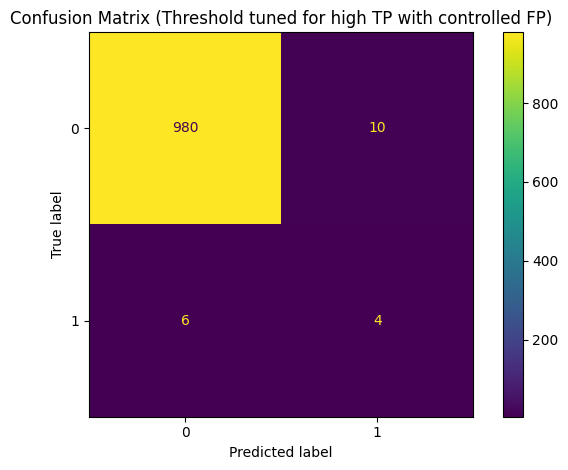

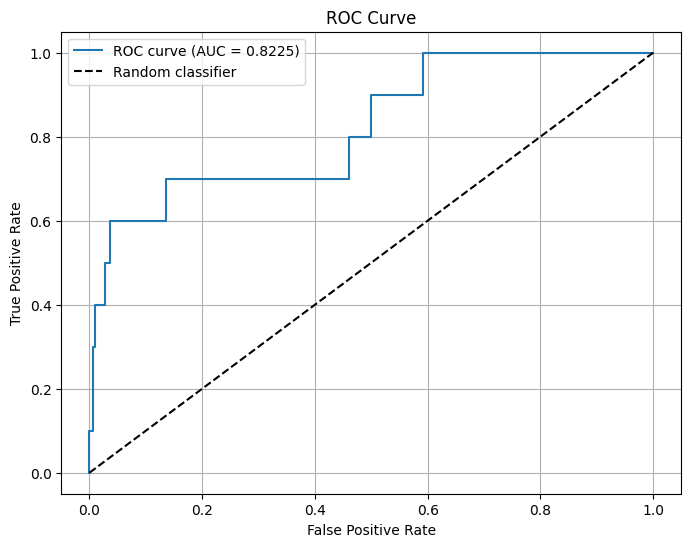

AUC-ROC: 0.8225252525252525
AUC-PR (Average Precision): 0.2203582561491537


,customer_id,ae_score,iso_score,risk_score,predicted_label
0,SYNID0100000167,0.842494,0.415997,0.373888,0
1,SYNID0100000431,0.318778,0.537956,0.425634,0
2,SYNID0100000485,0.086754,0.443258,0.247421,0
3,SYNID0100000539,25.030386,0.633618,0.679114,0
4,SYNID0100000932,14.468752,0.731331,0.753326,0


In [8]:

# 6) Threshold selection: maximize TP subject to a false-alarm constraint
#    Choose threshold on LABELED customers only, then apply to all.
labeled_mask = y.notna()
if labeled_mask.sum() == 0:
    raise ValueError("No labeled rows available to compute confusion matrix / sensitivity.")

y_true = y.loc[labeled_mask].astype(int).values
s = scores.loc[labeled_mask, "risk_score"].values

# Precision-recall curve (good for imbalanced)
prec, rec, thr = precision_recall_curve(y_true, s)
# thr has len = len(prec)-1
thr_full = np.r_[thr, thr[-1] + 1e-12]  # align lengths for convenience

# Utility to compute CM metrics at threshold
def cm_metrics(t):
    yp = (s >= t).astype(int)
    cm = confusion_matrix(y_true, yp, labels=[0,1])
    tn, fp, fn, tp = cm.ravel()
    precision = tp/(tp+fp+1e-12)
    recall = tp/(tp+fn+1e-12)        # sensitivity (TPR)
    fpr = fp/(fp+tn+1e-12)
    return tn, fp, fn, tp, precision, recall, fpr, cm

# Search thresholds (use thr from PR curve for speed)
cands = np.unique(thr)
best = None

for t in cands:
    tn, fp, fn, tp, p, r, fpr, cm = cm_metrics(t)
    if MAX_FPR is not None:
        if fpr > MAX_FPR: 
            continue
    if MIN_PRECISION is not None:
        if p < MIN_PRECISION:
            continue
    # objective: maximize TP, then minimize FP as tie-breaker
    key = (tp, -fp, p, r)
    if best is None or key > best[0]:
        best = (key, t, (tn, fp, fn, tp, p, r, fpr, cm))

if best is None:
    # fallback: maximize F2 if constraints are too strict
    beta = 2.0
    best_f = (-1, None, None)
    for t in cands:
        tn, fp, fn, tp, p, r, fpr, cm = cm_metrics(t)
        f2 = (1+beta**2)*p*r/(beta**2*p + r + 1e-12)
        if f2 > best_f[0]:
            best_f = (f2, t, (tn, fp, fn, tp, p, r, fpr, cm))
    chosen_t = best_f[1]
    tn, fp, fn, tp, p, r, fpr, cm = best_f[2]
    print("No threshold met constraints. Falling back to max F2.")
else:
    chosen_t = best[1]
    tn, fp, fn, tp, p, r, fpr, cm = best[2]

print(f"Chosen threshold: {chosen_t:.6f}")
print(f"TP={tp}  FP={fp}  FN={fn}  TN={tn}")
print(f"Precision={p:.4f}  Sensitivity/Recall={r:.4f}  FPR={fpr:.4f}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
disp.plot()
plt.title("Confusion Matrix (Threshold tuned for high TP with controlled FP)")
plt.tight_layout()
plt.show()

# 8) Plot ROC-AUC curve
from sklearn.metrics import roc_curve

# Assuming y_true and s are still in scope from chunk 6
fpr, tpr, thresholds = roc_curve(y_true, s)
auc = roc_auc_score(y_true, s)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

print("AUC-ROC:", roc_auc_score(y_true, s))
print("AUC-PR (Average Precision):", average_precision_score(y_true, s))

# Apply to all customers
scores["predicted_label"] = (scores["risk_score"] >= chosen_t).astype(int)
scores.head()


In [ ]:

# 7) Export in your required format (customer-level)
out = scores[[ID_COL, "predicted_label", "risk_score"]].copy()
out.to_csv("model_output.csv", index=False)
print("Saved model_output.csv with rows:", len(out))
